In [ ]:
'''
2025년 9월 23일 화요일 화이팅입니다~

어느새 이론 강의도 막바지에 접어들어 26강입니다!
목표는 이번 주 내로 이론강의를 떼고 
시험 예제풀이로 접어들며
이론강의 부분을 회독하며 내 것으로 만드는 작업에 들어가고 싶습니다.

제발~~
'''

## 딥러닝 기본 - 텐서플로우 실습

#### 1. Tensor

In [ ]:
'''
Tensor는 딥러닝 프레임워크에서 
데이터를 표현하고 처리하기 위한 다차원 배열구조이다

차원에 따라 스칼라(0차원), 벡터(1차원), 매트릭스(2차원) 등등으로 발전하며,
딥러닝에서 데이터를 다루는 기본 단위이다.
'''

In [1]:
!pip install tensorflow

In [2]:
import tensorflow as tf
print(tf.__version__)

2.20.0


In [18]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [4]:
# 학습 데이터 정의 - y = 3x + 5의 그래프

x = np.array([[1], [2], [3], [4], [5], [6], [7], [8], [9], [10]])

y = np.array([[8], [11], [14], [17], [20], [23], [26], [29], [32], [35]])

In [7]:
# Sequential 모델 정의
model = Sequential()

# Dense 층 추가
model.add(Dense(
    units=1,                # 출력층 뉴런 수 (회귀 문제니까 출력이 하나)
    activation='linear',    # 활성화 함수  ('relu', 'sigmoid', 'tanh'등의 옵션 가능)
    input_shape=[1],        # 입력 데이터 형태 (1차원인 x값을 학습시킴)
    kernel_initializer=tf.keras.initializers.GlorotUniform(seed=55),    # GlorotUniform 초기화 (가중치 랜덤초기화)
))

model.summary()     # 만들어진 모델에 대한 요약

c:\Users\16Z90P\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

In [8]:
# 모델 컴파일
model.compile(
    optimizer= 'sgd',               # 옵티마이져(학습 알고리즘) : SGD
    loss= 'mean_squared_error',     # 손실함수 : 평균제곱오차
    metrics=['mae']                 # 추가 매트릭(손실함수 외 성능지표) : 평균 절대오차
)

In [ ]:
# 모델 학습 - 머신러닝 때와 동일함
model.fit(x, y, epochs=200)

In [11]:
model.weights

[<Variable path=sequential/dense/kernel, shape=(1, 1), dtype=float32, value=[[3.1816113]]>,
 <Variable path=sequential/dense/bias, shape=(1,), dtype=float32, value=[3.735655]>]

In [13]:
weights, biases = model.layers[0].get_weights()

print(f'가중치:{weights}')
print(f'바이어스:{biases}')

가중치:[[3.1816113]]
바이어스:[3.735655]


In [14]:
# 예측할 데이터
new_data = np.array(([12],[14],[16],[18],[20]))

# 예측
prediction = model.predict(new_data)
print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
[[41.914993]
 [48.278214]
 [54.641438]
 [61.00466 ]
 [67.36788 ]]


In [ ]:
help(model.fit)

#### 2. TensorFlow 설치 및 실습

In [19]:
import numpy as np
import pandas as pd

In [20]:
data = pd.read_csv('datasets/CVD_cleaned.csv')

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 308854 entries, 0 to 308853
Data columns (total 19 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   General_Health                308854 non-null  object 
 1   Checkup                       308854 non-null  object 
 2   Exercise                      308854 non-null  object 
 3   Heart_Disease                 308854 non-null  object 
 4   Skin_Cancer                   308854 non-null  object 
 5   Other_Cancer                  308854 non-null  object 
 6   Depression                    308854 non-null  object 
 7   Diabetes                      308854 non-null  object 
 8   Arthritis                     308854 non-null  object 
 9   Sex                           308854 non-null  object 
 10  Age_Category                  308854 non-null  object 
 11  Height_(cm)                   308854 non-null  float64
 12  Weight_(kg)                   308854 non-nul

## 각 데이터 컬럼 설명

| 컬럼명                         | 설명                        | 비고                                                                 |
|------------------------------|-----------------------------|----------------------------------------------------------------------|
| General_Health               | 일반적인 건강 상태           | Poor : 매우 나쁨<br>Fair : 나쁨<br>Good : 보통<br>Very Good : 좋음<br>Excellent : 매우 좋음 |
| Checkup                      | 건강 검진 여부               | Within the past year : 1년 이내<br>Within the past 2 years : 2년 이내<br>Within the past 5 years : 5년 이내<br>5 or more years ago : 5년 이상 또는 그이상<br>Never : 한적 없음 |
| Exercise                     | 지난 한달동안 정기적인 운동 여부 | No : 아니요<br>Yes : 예                                            |
| Heart_Disease                | 심혈관 질환 여부              | No : 아니요<br>Yes : 예                                             |
| Skin_Cancer                  | 피부암 여부                  | No : 아니요<br>Yes : 예                                             |
| Other_Cancer                 | 기타 암 발생 여부            | No : 아니요<br>Yes : 예                                             |
| Depression                   | 우울증 여부                  | No : 아니요<br>Yes : 예                                             |
| Diabetes                     | 당뇨병 여부                  | No : 아니요<br>Yes : 예<br>No, pre-diabetes or borderline diabetes : 당뇨 전단계 또는 경계성 당뇨병 상태 <br>Yes, but female told only during pregnancy : 임신 중에만 당뇨병 진단을 받은 여성 |
| Arthritis                    | 관절염 여부                  | No : 아니요<br>Yes : 예                                             |
| sex                          | 응답자 성별                  | Male : 남자<br>Female : 여자                                       |
| Age_Category                 | 연령대별 구분(5 기준)        | 18 ~ 80세 이상까지 총 13개의 카테고리                                                                     |
| Height_(cm)                  | 응답자 신장                  |                                                                      |
| Weight_(kg)                  | 응답자 체중                  |                                                                      |
| BMI                          | 응답자 체질량 지수           |                                                                      |
| Smoking_History              | 흡연 여부                    | No : 아니요<br>Yes : 예                                             |
| Alcohol_Consumption          | 알코올 소비                  |                                                                      |
| Fruit_Consumption            | 과일 소비                    |                                                                      |
| Green_Vegetables_Consumption | 녹색 야채 소비               |                                                                      |
| FriedPotato_Consumption      | 감자 튀김 소비               |                                                                      |


In [21]:
data.head()

,General_Health,Checkup,Exercise,Heart_Disease,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,Age_Category,Height_(cm),Weight_(kg),BMI,Smoking_History,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
0,Poor,Within the past 2 years,No,No,No,No,No,No,Yes,Female,70-74,150.0,32.66,14.54,Yes,0.0,30.0,16.0,12.0
1,Very Good,Within the past year,No,Yes,No,No,No,Yes,No,Female,70-74,165.0,77.11,28.29,No,0.0,30.0,0.0,4.0
2,Very Good,Within the past year,Yes,No,No,No,No,Yes,No,Female,60-64,163.0,88.45,33.47,No,4.0,12.0,3.0,16.0
3,Poor,Within the past year,Yes,Yes,No,No,No,Yes,No,Male,75-79,180.0,93.44,28.73,No,0.0,30.0,30.0,8.0
4,Good,Within the past year,No,No,No,No,No,No,No,Male,80+,191.0,88.45,24.37,Yes,0.0,8.0,4.0,0.0


In [22]:
data.describe()

,Height_(cm),Weight_(kg),BMI,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
count,308854.000000,308854.000000,308854.000000,308854.000000,308854.000000,308854.000000,308854.000000
mean,170.615249,83.588655,28.626211,5.096366,29.835200,15.110441,6.296616
std,10.658026,21.343210,6.522323,8.199763,24.875735,14.926238,8.582954
min,91.000000,24.950000,12.020000,0.000000,0.000000,0.000000,0.000000
25%,163.000000,68.040000,24.210000,0.000000,12.000000,4.000000,2.000000
50%,170.000000,81.650000,27.440000,1.000000,30.000000,12.000000,4.000000
75%,178.000000,95.250000,31.850000,6.000000,30.000000,20.000000,8.000000
max,241.000000,293.020000,99.330000,30.000000,120.000000,128.000000,128.000000


In [23]:
# 결측치 확인
data.isna().sum()

General_Health                  0
Checkup                         0
Exercise                        0
Heart_Disease                   0
Skin_Cancer                     0
Other_Cancer                    0
Depression                      0
Diabetes                        0
Arthritis                       0
Sex                             0
Age_Category                    0
Height_(cm)                     0
Weight_(kg)                     0
BMI                             0
Smoking_History                 0
Alcohol_Consumption             0
Fruit_Consumption               0
Green_Vegetables_Consumption    0
FriedPotato_Consumption         0
dtype: int64

In [24]:
# 범주형 데이터 원-핫 인코딩

# 대상 컬럼 리스트 (범주형)
one_hot_columns = [
    'General_Health', 'Checkup', 'Diabetes', 'Exercise',
    'Skin_Cancer', 'Other_Cancer', 'Age_Category',
    'Depression', 'Arthritis', 'Sex', 'Smoking_History'
]

# 원핫 인코딩 진행
data = pd.get_dummies(data, columns=one_hot_columns, drop_first=True)   # drop_first 는 이지선다에서 칼럼을 두개 만들지 않도록 (다중공선성)

data.head()

# 독립변수에 원핫인코딩을 적용하는 이유는
# True/False 로 나오기 때문에 절대적인 크기 자체를 가지지 않아 
# 잘못된 학습이 되지 않게 하기 위함임
# 다중공산성 - 분산 구할때 n-1 자유도로 나누는 것과 같음

,Heart_Disease,Height_(cm),Weight_(kg),BMI,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption,General_Health_Fair,General_Health_Good,...,Age_Category_55-59,Age_Category_60-64,Age_Category_65-69,Age_Category_70-74,Age_Category_75-79,Age_Category_80+,Depression_Yes,Arthritis_Yes,Sex_Male,Smoking_History_Yes
0,No,150.0,32.66,14.54,0.0,30.0,16.0,12.0,False,False,...,False,False,False,True,False,False,False,True,False,True
1,Yes,165.0,77.11,28.29,0.0,30.0,0.0,4.0,False,False,...,False,False,False,True,False,False,False,False,False,False
2,No,163.0,88.45,33.47,4.0,12.0,3.0,16.0,False,False,...,False,True,False,False,False,False,False,False,False,False
3,Yes,180.0,93.44,28.73,0.0,30.0,30.0,8.0,False,False,...,False,False,False,False,True,False,False,False,True,False
4,No,191.0,88.45,24.37,0.0,8.0,4.0,0.0,False,True,...,False,False,False,False,False,True,False,False,True,True


In [ ]:
help(pd.get_dummies)

In [25]:
# 종속변수에 해당하는 Heart_Disease 컬럼 레이블인코딩 (Yes/No로 되어있음)
from sklearn.preprocessing import LabelEncoder

# LabelEncoder 객체 생성
label_encoder = LabelEncoder()

# Heart_Disease 컬럼 레이블 인코딩
data['Heart_Disease'] = label_encoder.fit_transform(data['Heart_Disease'])

# 결과 확인
data[['Heart_Disease']].head()

# 종속변수에 레이블 인코딩을 하는 이유는 또한 마찬가지로 어떤 클라스에 속하는가가 중요하기 때문에 
# 레이블 인코딩(0, 1, 2, 3, 4 ~)을 하는 것이다.
# 크기를 가져도 학습 과정에 영향을 주지 않기 때문이기도 하다.

,Heart_Disease
0,0
1,1
2,0
3,1
4,0


In [ ]:
help(LabelEncoder)

In [26]:
from sklearn.model_selection import train_test_split

# 입력 데이터(feature)와 출력 데이터(target) 분리
x = data.drop(columns=['Heart_Disease'])
y = data['Heart_Disease']

# 학습Set과 테스트Set 
x_train, x_test, y_train, y_test = train_test_split(x, y,
                                                    test_size=0.2,
                                                    stratify=y,     # Set내 계층간 비율 유지
                                                    random_state=1)

print('학습 데이터셋 크기 :', x_train.shape, y_train.shape)
print('test 데이터셋 크기 :', x_test.shape, y_test.shape)

학습 데이터셋 크기 : (247083, 37) (247083,)
test 데이터셋 크기 : (61771, 37) (61771,)


In [ ]:
# 종속변수를 제외한 데이터(x_train, x_test) 표준화
# 범주형 데이터는 앞서 원-핫 인코딩과 레이블 인코딩등의 전처리를 거치고
# 수치형 데이터는 set 별로 split 후에 표준화 전처리를 거친다
from sklearn.preprocessing import MinMaxScaler

# 스케일링 대상 컬럼
scaling_columns = [
    'Height_(cm)', 'Weight_(kg)', 'BMI', 
    'Alcohol_Consumption', 'Fruit_Consumption', 
    'Green_Vegetables_Consumption', 'FriedPotato_Consumption'
]

# Min-Max Scaler 객체 생성
scaler = MinMaxScaler()

# 학습 데이터에서 스케일링 대상 컬럼만 변환
x_train_scaled = x_train.copy()
x_train_scaled[scaling_columns] = scaler.fit_transform(x_train[scaling_columns])

# 테스트 데이터에서 동일한 스케일링 적용
x_test_scaled = x_test.copy()
x_test_scaled[scaling_columns] = scaler.transform(x_test[scaling_columns])

# 결과 확인
print("스케일링된 학습 데이터 (일부):\n", x_train_scaled[scaling_columns].head().to_string(index=False))
print("\n스케일링된 테스트 데이터 (일부):\n", x_test_scaled[scaling_columns].head().to_string(index=False))

스케일링된 학습 데이터 (일부):
  Height_(cm)  Weight_(kg)      BMI  Alcohol_Consumption  Fruit_Consumption  Green_Vegetables_Consumption  FriedPotato_Consumption
    0.560000     0.303378 0.259764             0.000000           0.250000                      0.234375                 0.234375
    0.513333     0.227113 0.213607             1.000000           0.166667                      0.125000                 0.093750
    0.526667     0.159330 0.131371             0.400000           0.500000                      0.234375                 0.234375
    0.613333     0.186458 0.120147             0.333333           0.125000                      0.218750                 0.046875
    0.593333     0.213549 0.153018             0.166667           0.200000                      0.007812                 0.468750

스케일링된 테스트 데이터 (일부):
  Height_(cm)  Weight_(kg)      BMI  Alcohol_Consumption  Fruit_Consumption  Green_Vegetables_Consumption  FriedPotato_Consumption
    0.526667     0.176257 0.149353             0

In [ ]:
# 딥러닝 모델 생성
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# 시드 고정
np.random.seed(42)
tf.random.set_seed(42)

# 모델 생성
model = Sequential()

# 모델 구성

# 입력층
model.add(Dense(units=64, activation='relu', input_shape=(x_train.shape[1],)))

# 은닉층 + 드롭아웃 레이어
model.add(Dense(units=32, activation='relu'))
model.add(Dense(units=16, activation='relu'))
model.add(Dropout(rate=0.2))  # 드롭아웃 비율 20%
model.add(Dense(units=8, activation='relu'))
model.add(Dropout(rate=0.2))  # 드롭아웃 비율 20%
model.add(Dense(units=4, activation='relu'))
model.add(Dropout(rate=0.2))  # 드롭아웃 비율 20%

# 출력층
model.add(Dense(units=1, activation='sigmoid'))  # 이진 분류 문제에 적합한 sigmoid 활성화 함수

# 모델 요약
model.summary()

c:\Users\16Z90P\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,217 (20.38 KB)

 Trainable params: 5,217 (20.38 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
# 모델 컴파일

model.compile(
    optimizer='adam',           # Adam 옵티마이저 (bias & 가중치 업데이트)
    loss='binary_crossentropy', # 이진 분류 손실함수
    metrics=['accuracy']        # 평가 지표
)

In [33]:
# 모델 학습

from tensorflow.keras.callbacks import EarlyStopping

# early stopping 콜백 정의
early_stopping = EarlyStopping(
    monitor='val_loss',    # 검증 손실(val_loss)을 기준으로 모니터링
    patience=5,            # 개선되지 않는 에폭 수 (5회 연속 개선되지 않으면 학습 중단)
    restore_best_weights=True  # 가장 성능이 좋은 모델의 가중치를 복원
)

# 모델 학습
history = model.fit(
    x_train_scaled,        # 학습 데이터 (입력)
    y_train,               # 학습 데이터 (타겟)
    validation_split=0.2,  # 학습 데이터의 20%를 검증 데이터로 사용
    epochs=50,            # 최대 학습 반복 횟수
    batch_size=32,         # 배치 크기
    callbacks=[early_stopping],  # 얼리 스탑핑 콜백 추가
    verbose=1              # 학습 과정 출력 (1: 상세 출력)
)


Epoch 1/50
6178/6178 ━━━━━━━━━━━━━━━━━━━━ 17s 2ms/step - accuracy: 0.9181 - loss: 0.2679 - val_accuracy: 0.9190 - val_loss: 0.2261
Epoch 2/50
6178/6178 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step - accuracy: 0.9192 - loss: 0.2325 - val_accuracy: 0.9190 - val_loss: 0.2269
Epoch 3/50
6178/6178 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - accuracy: 0.9190 - loss: 0.2311 - val_accuracy: 0.9190 - val_loss: 0.2258
Epoch 4/50
6178/6178 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - accuracy: 0.9189 - loss: 0.2303 - val_accuracy: 0.9190 - val_loss: 0.2245
Epoch 5/50
6178/6178 ━━━━━━━━━━━━━━━━━━━━ 27s 4ms/step - accuracy: 0.9192 - loss: 0.2293 - val_accuracy: 0.9190 - val_loss: 0.2259
Epoch 6/50
6178/6178 ━━━━━━━━━━━━━━━━━━━━ 37s 6ms/step - accuracy: 0.9191 - loss: 0.2290 - val_accuracy: 0.9190 - val_loss: 0.2260
Epoch 7/50
6178/6178 ━━━━━━━━━━━━━━━━━━━━ 32s 5ms/step - accuracy: 0.9188 - loss: 0.2295 - val_accuracy: 0.9190 - val_loss: 0.2250
Epoch 8/50
6178/6178 ━━━━━━━━━━━━━━━━━━━━ 28s 5ms/step - accuracy: 0.9193 - loss: 0

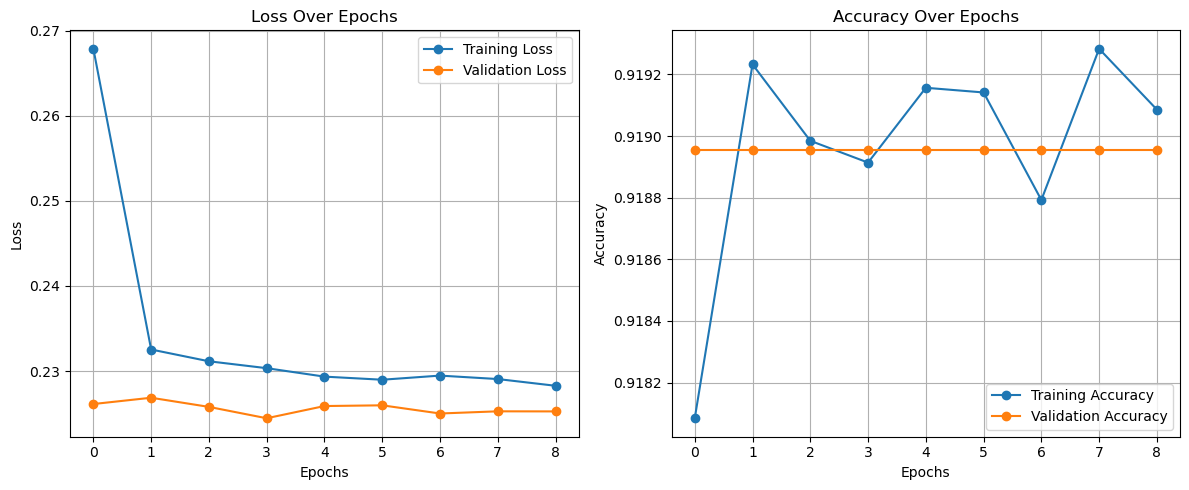

In [34]:
# 시각화
import matplotlib.pyplot as plt

# 훈련 및 검증 손실 시각화
def plot_training_history(history):
    # 손실 그래프
    plt.figure(figsize=(12, 5))
    
    # 손실 값 (Loss)
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss', marker='o')
    plt.plot(history.history['val_loss'], label='Validation Loss', marker='o')
    plt.title('Loss Over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    
    # 정확도 값 (Accuracy)
    plt.subplot(1, 2, 2)
    if 'accuracy' in history.history:
        plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
        plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
        plt.title('Accuracy Over Epochs')
        plt.xlabel('Epochs')
        plt.ylabel('Accuracy')
        plt.legend()
        plt.grid(True)
    
    # 그래프 출력
    plt.tight_layout()
    plt.show()

# 함수 호출: 모델 학습 결과 시각화
plot_training_history(history)


In [35]:
# 예측

prediction = model.predict(x_test_scaled)
print(prediction)

1931/1931 ━━━━━━━━━━━━━━━━━━━━ 2s 836us/step
[[0.01049075]
 [0.16238558]
 [0.01640334]
 ...
 [0.09536208]
 [0.17952283]
 [0.00653643]]


In [36]:
# 확률 기반 예측 결과를 변환 (0 or 1)
binary_prediction = (prediction > 0.5).astype(int)

In [ ]:
for pred, true in zip(binary_prediction, y_test):
    print(f"예측: {pred}, 실제: {true}, 일치 여부: {'O' if pred == true else 'X'}")


▶ 정확도(Accuracy): 0.92

▶ 혼동행렬:
[[56777     0]
 [ 4994     0]]


c:\Users\16Z90P\anaconda3\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\16Z90P\anaconda3\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\16Z90P\anaconda3\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\16Z90P\anaconda3\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\16Z90P\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\16Z90P\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51228 (\N{HANGUL SYLLAB

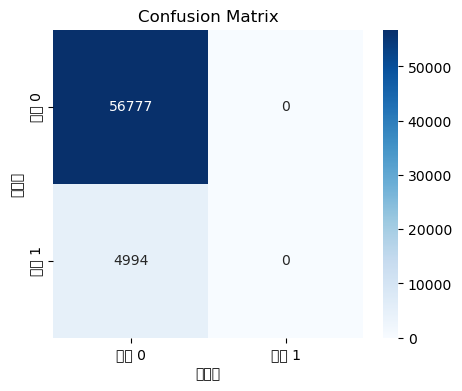


▶ 분류 성능 보고서:
              precision    recall  f1-score   support

           0       0.92      1.00      0.96     56777
           1       0.00      0.00      0.00      4994

    accuracy                           0.92     61771
   macro avg       0.46      0.50      0.48     61771
weighted avg       0.84      0.92      0.88     61771



c:\Users\16Z90P\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\16Z90P\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\16Z90P\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [39]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns

# 정확도
acc = accuracy_score(y_test, binary_prediction)
print(f"\n▶ 정확도(Accuracy): {acc:.2f}")

# 혼동행렬
cm = confusion_matrix(y_test, binary_prediction)
print("\n▶ 혼동행렬:")
print(cm)

# 시각화
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['예측 0', '예측 1'], yticklabels=['실제 0', '실제 1'])
plt.title("Confusion Matrix")
plt.ylabel("실제값")
plt.xlabel("예측값")
plt.show()

# 분류 리포트
print("\n▶ 분류 성능 보고서:")
print(classification_report(y_test, binary_prediction))